In [ ]:
from google.colab import drive
import os
import shutil

# Ensure the mount point is clean
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
        print('Unmounted existing Google Drive.')
    except ValueError:
        print('Google Drive was not mounted or could not be unmounted, proceeding to clean directory.')

    # Attempt to remove the directory if it's not a mount point anymore
    if os.path.ismount('/content/drive'):
        print('/content/drive is still a mount point, cannot remove.')
    else:
        try:
            shutil.rmtree('/content/drive')
            print('Removed old /content/drive directory.')
        except OSError as e:
            print(f'Error removing /content/drive: {e}')

# Recreate an empty directory for the mount point
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Unmounted existing Google Drive.
Removed old /content/drive directory.
Mounted at /content/drive


In [ ]:
import os

# Main IoT-23 folder in Google Drive
data_path = "/content/drive/MyDrive/DSP 2"

# Folder to save CSVs
output_csv_path = "/content/drive/MyDrive/DSP 2/IoT23_CSVs"

os.makedirs(output_csv_path, exist_ok=True)

print("Output folder ready.")

Output folder ready.


In [ ]:
conn_files = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file == "conn.log.labeled":
            full_path = os.path.join(root, file)
            conn_files.append(full_path)

print(f"Found {len(conn_files)} conn.log.labeled files.\n")

for f in conn_files:
    print(f)

Found 10 conn.log.labeled files.

/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-20-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-9-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-Honeypot-Capture-4-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-Honeypot-Capture-5-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-Honeypot-Capture-7-1/Somfy-01/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-3-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-42-1/bro/conn.log.labeled
/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-17-1/bro/conn.log.labeled


In [ ]:
if conn_files:
    first_conn_file = conn_files[2]
    print(f"Viewing content of: {first_conn_file}\n")
    with open(first_conn_file, 'r') as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 9: # Print first 10 lines
                break
else:
    print("No 'conn.log.labeled' files were found.")

Viewing content of: /content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-9-1/bro/conn.log.labeled

#separator \x09
#set_separator	,
#empty_field	(empty)
#unset_field	-
#path	conn
#open	2018-08-17-14-46-17
#fields	ts	uid	id.orig_h	id.orig_p	id.resp_h	id.resp_p	proto	service	duration	orig_bytes	resp_bytes	conn_state	local_orig	local_resp	missed_bytes	history	orig_pkts	orig_ip_bytes	resp_pkts	resp_ip_bytes	tunnel_parents   label   detailed-label
#types	time	string	addr	port	addr	port	enum	string	interval	count	count	string	bool	bool	count	string	count	count	count	count	set[string]   string   string
1532510451.648888	CnR6zKxrWbFw26ua7	192.168.100.111	40008	46.28.110.244	123	udp	-	0.004751	48	48	SF	-	-	0	Dd	1	76	1	76	(empty)   Benign   -
1532511003.118878	CcfURS3zgEMzX0RqTc	192.168.100.102	57849	192.168.100.111	22	tcp	-	108.421563	2376	96	OTH	-	-	0	DAd	5	332	2	200	(empty)   Benign   -


In [ ]:
if conn_files:
    first_conn_file = conn_files[2]
    column_names = []
    with open(first_conn_file, 'r') as f:
        for line in f:
            if line.startswith('#fields'):
                # Split the line by tab and take elements after the first one
                column_names = line.strip().split('\t')[1:]
                break

    if column_names:
        print(f"Column names from '{first_conn_file}':")
        for col in column_names:
            print(f"- {col}")
    else:
        print(f"Could not find column names in '{first_conn_file}'.")
else:
    print("No 'conn.log.labeled' files were found to extract column names.")

Column names from '/content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-9-1/bro/conn.log.labeled':
- ts
- uid
- id.orig_h
- id.orig_p
- id.resp_h
- id.resp_p
- proto
- service
- duration
- orig_bytes
- resp_bytes
- conn_state
- local_orig
- local_resp
- missed_bytes
- history
- orig_pkts
- orig_ip_bytes
- resp_pkts
- resp_ip_bytes
- tunnel_parents   label   detailed-label


In [ ]:
if conn_files:
    # Selecting the first file from the list to preview
    file_to_preview = conn_files[0]
    print(f"Viewing content of: {file_to_preview}\n")
    with open(file_to_preview, 'r') as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 9: # Print first 10 lines
                break
else:
    print("No 'conn.log.labeled' files were found.")

Viewing content of: /content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled

#separator \x09
#set_separator	,
#empty_field	(empty)
#unset_field	-
#path	conn
#open	2019-03-15-14-50-49
#fields	ts	uid	id.orig_h	id.orig_p	id.resp_h	id.resp_p	proto	service	duration	orig_bytes	resp_bytes	conn_state	local_orig	local_resp	missed_bytes	history	orig_pkts	orig_ip_bytes	resp_pkts	resp_ip_bytes	tunnel_parents   label   detailed-label
#types	time	string	addr	port	addr	port	enum	string	interval	count	count	string	bool	bool	count	string	count	count	count	count	set[string]   string   string
1545403816.962094	CrDn63WjJEmrWGjqf	192.168.1.195	41040	185.244.25.235	80	tcp	-	3.139211	0	0	S0	-	-	0	S	3	180	0	0	-   Benign   -
1545403824.181240	CY9lJW3gh1Eje4usP6	192.168.1.195	41040	185.244.25.235	80	tcp	-	-	-	-	S0	-	-	0	S	1	60	0	0	-   Benign   -


In [ ]:
import pandas as pd
import csv

for file_path in conn_files:

    print(f"\nProcessing: {file_path}")

    scenario_name = file_path.split("/")[-3]

    output_file = os.path.join(
        output_csv_path,
        f"{scenario_name}.csv"
    )

    columns = None

    with open(file_path, 'r') as infile, \
         open(output_file, 'w', newline='') as outfile:

        writer = None

        for line in infile:

            # Extract columns
            if line.startswith("#fields"):
                columns = line.strip().split('\t')[1:]

                writer = csv.writer(outfile)
                writer.writerow(columns)

            # Skip metadata lines
            elif line.startswith("#"):
                continue

            else:
                row = line.strip().split('\t')

                # Replace Zeek missing values
                row = [None if x == "-" else x for x in row]

                if writer:
                    writer.writerow(row)

    print(f"Saved: {output_file}")


Processing: /content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled
Saved: /content/drive/MyDrive/DSP 2/IoT23_CSVs/CTU-IoT-Malware-Capture-34-1.csv

Processing: /content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-20-1/bro/conn.log.labeled
Saved: /content/drive/MyDrive/DSP 2/IoT23_CSVs/CTU-IoT-Malware-Capture-20-1.csv

Processing: /content/drive/MyDrive/DSP 2/CTU-IoT-Malware-Capture-9-1/bro/conn.log.labeled
Saved: /content/drive/MyDrive/DSP 2/IoT23_CSVs/CTU-IoT-Malware-Capture-9-1.csv

Processing: /content/drive/MyDrive/DSP 2/CTU-Honeypot-Capture-4-1/bro/conn.log.labeled
Saved: /content/drive/MyDrive/DSP 2/IoT23_CSVs/CTU-Honeypot-Capture-4-1.csv

Processing: /content/drive/MyDrive/DSP 2/CTU-Honeypot-Capture-5-1/bro/conn.log.labeled
Saved: /content/drive/MyDrive/DSP 2/IoT23_CSVs/CTU-Honeypot-Capture-5-1.csv

Processing: /content/drive/MyDrive/DSP 2/CTU-Honeypot-Capture-7-1/Somfy-01/bro/conn.log.labeled
Saved: /content/drive/MyDrive/DSP 2/IoT23_CSVs/Somfy-01.csv



In [ ]:
sample_df = pd.read_csv(
    "/content/drive/MyDrive/DSP 2/IoT23_CSVs/CTU-IoT-Malware-Capture-34-1.csv"
)

sample_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents label detailed-label
0,1.545404e+09,CrDn63WjJEmrWGjqf,192.168.1.195,41040,185.244.25.235,80,tcp,NaN,3.139211,0.0,...,S0,NaN,NaN,0,S,3,180,0,0,- Benign -
1,1.545404e+09,CY9lJW3gh1Eje4usP6,192.168.1.195,41040,185.244.25.235,80,tcp,NaN,NaN,NaN,...,S0,NaN,NaN,0,S,1,60,0,0,- Benign -
2,1.545404e+09,CcFXLynukEDnUlvgl,192.168.1.195,41040,185.244.25.235,80,tcp,NaN,NaN,NaN,...,S0,NaN,NaN,0,S,1,60,0,0,- Benign -
3,1.545404e+09,CDrkrSobGYxHhYfth,192.168.1.195,41040,185.244.25.235,80,tcp,http,1.477656,149.0,...,SF,NaN,NaN,2896,ShADadttcfF,94,5525,96,139044,- Benign -
4,1.545404e+09,CTWZQf2oJSvq6zmPAc,192.168.1.195,41042,185.244.25.235,80,tcp,NaN,3.147116,0.0,...,S0,NaN,NaN,0,S,3,180,0,0,- Benign -


In [ ]:
print(sample_df.isnull().sum())

ts                                             0
uid                                            0
id.orig_h                                      0
id.orig_p                                      0
id.resp_h                                      0
id.resp_p                                      0
proto                                          0
service                                    21298
duration                                   17824
orig_bytes                                 17824
resp_bytes                                 17824
conn_state                                     0
local_orig                                 23145
local_resp                                 23145
missed_bytes                                   0
history                                        0
orig_pkts                                      0
orig_ip_bytes                                  0
resp_pkts                                      0
resp_ip_bytes                                  0
tunnel_parents   lab

In [ ]:
import os
import gc
import numpy as np
import pandas as pd

# =========================================================
# PATHS
# =========================================================

input_csv_folder = "/content/drive/MyDrive/DSP 2/IoT23_CSVs"
output_clean_folder = "/content/drive/MyDrive/DSP 2/IoT23_Cleaned"

os.makedirs(output_clean_folder, exist_ok=True)

# =========================================================
# SELECTED SCENARIOS
# =========================================================

selected_scenarios = [
    "CTU-IoT-Malware-Capture-34-1",
     "CTU-IoT-Malware-Capture-20-1",
     "CTU-IoT-Malware-Capture-42-1",
     "CTU-IoT-Malware-Capture-17-1",
     "CTU-IoT-Malware-Capture-9-1",
     "CTU-IoT-Malware-Capture-1-1",
     "CTU-IoT-Malware-Capture-3-1",
     "CTU-Honeypot-Capture-4-1",
     "CTU-Honeypot-Capture-5-1",
     "CTU-Honeypot-Capture-7-1"
]

# =========================================================
# NUMERICAL COLUMNS
# =========================================================

numerical_cols = [
    'duration',
    'orig_bytes',
    'resp_bytes',
    'missed_bytes',
    'orig_pkts',
    'orig_ip_bytes',
    'resp_pkts',
    'resp_ip_bytes'
]

# =========================================================
# CHUNK SIZE
# =========================================================

CHUNK_SIZE = 25000

# =========================================================
# PROCESS FILES
# =========================================================

all_files = os.listdir(input_csv_folder)

for file_name in all_files:

    if not file_name.endswith(".csv"):
        continue

    scenario_name = file_name.replace(".csv", "")

    if scenario_name not in selected_scenarios:
        continue

    print(f"\nProcessing: {scenario_name}")

    file_path = os.path.join(input_csv_folder, file_name)

    output_path = os.path.join(
        output_clean_folder,
        f"{scenario_name}_cleaned.csv"
    )

    first_chunk = True

    # =====================================================
    # READ IN CHUNKS
    # =====================================================

    for chunk in pd.read_csv(
        file_path,
        chunksize=CHUNK_SIZE,
        low_memory=True
    ):

        # =================================================
        # FIX MERGED LABEL COLUMN
        # =================================================

        merged_col = 'tunnel_parents   label   detailed-label'

        if merged_col in chunk.columns:

            split_cols = (
                chunk[merged_col]
                .astype(str)
                .str.split(r'\s{2,}', expand=True)
            )

            if split_cols.shape[1] >= 3:

                chunk['tunnel_parents'] = split_cols[0]
                chunk['label'] = split_cols[1]
                chunk['detailed-label'] = split_cols[2]

            chunk.drop(columns=[merged_col], inplace=True)

        # =================================================
        # HANDLE LABELS
        # =================================================

        if 'label' not in chunk.columns:
            chunk['label'] = 'Unknown'

        if 'detailed-label' not in chunk.columns:
            chunk['detailed-label'] = 'Unknown'

        chunk['label'] = chunk['label'].fillna('Unknown')

        chunk['detailed-label'] = (
            chunk['detailed-label']
            .replace('-', 'Benign')
            .fillna('Benign')
        )

        # Normalize labels
        chunk['label'] = (
            chunk['label']
            .astype(str)
            .str.strip()
            .str.capitalize()
        )

        chunk['detailed-label'] = (
            chunk['detailed-label']
            .astype(str)
            .str.strip()
        )

        # =================================================
        # REMOVE UNNECESSARY COLUMNS
        # =================================================

        cols_to_remove = [
            'uid',
            'id.orig_h',
            'id.resp_h',
            'id.orig_p',
            'id.resp_p',
            'local_orig',
            'local_resp',
            'tunnel_parents',
            'ts'
        ]

        existing_remove_cols = [
            col for col in cols_to_remove
            if col in chunk.columns
        ]

        chunk.drop(columns=existing_remove_cols, inplace=True)

        # =================================================
        # HANDLE NUMERICAL COLUMNS
        # =================================================

        for col in numerical_cols:

            if col in chunk.columns:

                chunk[col] = chunk[col].replace('-', np.nan)

                chunk[col] = pd.to_numeric(
                    chunk[col],
                    errors='coerce'
                )

                chunk[col] = chunk[col].fillna(0)

        # Reduce memory usage
        for col in numerical_cols:

            if col in chunk.columns:

                chunk[col] = chunk[col].astype('float32')

        # =================================================
        # HANDLE CATEGORICAL COLUMNS
        # =================================================

        categorical_cols = [
            'proto',
            'service',
            'conn_state',
            'history'
        ]

        for col in categorical_cols:

            if col in chunk.columns:

                chunk[col] = (
                    chunk[col]
                    .astype(str)
                    .replace('-', 'Unknown')
                    .fillna('Unknown')
                )

        # =================================================
        # FEATURE ENGINEERING
        # =================================================

        chunk['total_pkts'] = (
            chunk['orig_pkts'] +
            chunk['resp_pkts']
        )

        chunk['total_bytes'] = (
            chunk['orig_ip_bytes'] +
            chunk['resp_ip_bytes']
        )

        chunk['byte_ratio'] = (
            chunk['orig_bytes'] /
            (chunk['resp_bytes'] + 1)
        )

        chunk['packet_ratio'] = (
            chunk['orig_pkts'] /
            (chunk['resp_pkts'] + 1)
        )

        chunk['packets_per_second'] = (
            chunk['total_pkts'] /
            (chunk['duration'] + 1)
        )

        chunk['bytes_per_second'] = (
            chunk['total_bytes'] /
            (chunk['duration'] + 1)
        )

        # Replace infinite values
        chunk.replace([np.inf, -np.inf], 0, inplace=True)

        # =================================================
        # REMOVE DUPLICATES
        # =================================================

        before_dedup = len(chunk)

        chunk = chunk.drop_duplicates()

        after_dedup = len(chunk)

        print(f"Removed {before_dedup - after_dedup} duplicate rows")

        # =================================================
        # DOWNSAMPLE LARGE BENIGN TRAFFIC
        # =================================================

        if 'label' in chunk.columns:

            benign_chunk = chunk[chunk['label'] == 'Benign']
            malicious_chunk = chunk[chunk['label'] != 'Benign']

            # Reduce overly large benign traffic
            if len(benign_chunk) > 20000:

                benign_chunk = benign_chunk.sample(
                    n=20000,
                    random_state=42
                )

            # Merge back
            chunk = pd.concat([
                benign_chunk,
                malicious_chunk
            ])

        # =================================================
        # ADD SCENARIO COLUMN
        # =================================================

        chunk['scenario'] = scenario_name

        # =================================================
        # KEEP FINAL COLUMNS
        # =================================================

        final_keep_cols = [
            'proto',
            'service',
            'duration',
            'conn_state',
            'history',

            'orig_bytes',
            'resp_bytes',
            'orig_pkts',
            'resp_pkts',
            'orig_ip_bytes',
            'resp_ip_bytes',

            'missed_bytes',

            'total_pkts',
            'total_bytes',
            'byte_ratio',
            'packet_ratio',
            'packets_per_second',
            'bytes_per_second',

            'label',
            'detailed-label',

            'scenario'
        ]

        existing_keep_cols = [
            col for col in final_keep_cols
            if col in chunk.columns
        ]

        chunk = chunk[existing_keep_cols]

        # =================================================
        # SAVE CHUNK
        # =================================================

        chunk.to_csv(
            output_path,
            mode='a',
            index=False,
            header=first_chunk
        )

        first_chunk = False

        print(f"Processed chunk: {len(chunk)} rows")

        # =================================================
        # MEMORY CLEANUP
        # =================================================

        del chunk
        gc.collect()

    print(f"Finished: {scenario_name}")

print("\nAll files processed successfully.")


Processing: CTU-Honeypot-Capture-7-1
Removed 6 duplicate rows
Processed chunk: 124 rows
Finished: CTU-Honeypot-Capture-7-1

All files processed successfully.


In [ ]:
import os
import pandas as pd

cleaned_folder = "/content/drive/MyDrive/DSP 2/IoT23_Cleaned"

all_dfs = []

for file_name in os.listdir(cleaned_folder):

    if file_name.endswith(".csv"):

        file_path = os.path.join(cleaned_folder, file_name)

        print(f"Loading: {file_name}")

        df = pd.read_csv(file_path)

        all_dfs.append(df)

# Merge all cleaned datasets
final_df = pd.concat(all_dfs, ignore_index=True)

print("Final Shape:", final_df.shape)

# Save merged dataset
final_output_path = "/content/drive/MyDrive/DSP 2/Final IoT23.csv"

final_df.to_csv(final_output_path, index=False)

print("Merged dataset saved.")

Loading: CTU-IoT-Malware-Capture-34-1_cleaned.csv
Loading: CTU-IoT-Malware-Capture-20-1_cleaned.csv
Loading: CTU-Honeypot-Capture-4-1_cleaned.csv
Loading: CTU-IoT-Malware-Capture-9-1_cleaned.csv
Loading: CTU-Honeypot-Capture-5-1_cleaned.csv
Loading: CTU-IoT-Malware-Capture-1-1_cleaned.csv
Loading: CTU-IoT-Malware-Capture-3-1_cleaned.csv
Loading: CTU-IoT-Malware-Capture-42-1_cleaned.csv
Loading: CTU-IoT-Malware-Capture-17-1_cleaned.csv
Loading: CTU-Honeypot-Capture-7-1_cleaned.csv
Final Shape: (347378, 21)
Merged dataset saved.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Final IoT23.csv to Final IoT23.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Final IoT23.csv')
df.head()

,proto,service,duration,conn_state,history,orig_bytes,resp_bytes,orig_pkts,resp_pkts,orig_ip_bytes,...,missed_bytes,total_pkts,total_bytes,byte_ratio,packet_ratio,packets_per_second,bytes_per_second,label,detailed-label,scenario
0,tcp,NaN,3.139211,S0,S,0.0,0.0,3.0,0.0,180.0,...,0.0,3.0,180.0,0.000000,3.000000,0.724776,43.486553,Benign,Benign,CTU-IoT-Malware-Capture-34-1
1,tcp,NaN,0.000000,S0,S,0.0,0.0,1.0,0.0,60.0,...,0.0,1.0,60.0,0.000000,1.000000,1.000000,60.000000,Benign,Benign,CTU-IoT-Malware-Capture-34-1
2,tcp,http,1.477656,SF,ShADadttcfF,149.0,128252.0,94.0,96.0,5525.0,...,2896.0,190.0,144569.0,0.001162,0.969072,76.685390,58349.105000,Benign,Benign,CTU-IoT-Malware-Capture-34-1
3,tcp,NaN,3.147116,S0,S,0.0,0.0,3.0,0.0,180.0,...,0.0,3.0,180.0,0.000000,3.000000,0.723394,43.403660,Benign,Benign,CTU-IoT-Malware-Capture-34-1
4,tcp,http,1.305004,SF,ShADadttcfF,151.0,128348.0,96.0,92.0,5699.0,...,5792.0,188.0,138839.0,0.001176,1.032258,81.561676,60233.730000,Benign,Benign,CTU-IoT-Malware-Capture-34-1


In [ ]:
print(df.isnull().sum())

proto                      0
service               323090
duration                   0
conn_state                 0
history                 9140
orig_bytes                 0
resp_bytes                 0
orig_pkts                  0
resp_pkts                  0
orig_ip_bytes              0
resp_ip_bytes              0
missed_bytes               0
total_pkts                 0
total_bytes                0
byte_ratio                 0
packet_ratio               0
packets_per_second         0
bytes_per_second           0
label                      0
detailed-label             0
scenario                   0
dtype: int64


In [ ]:
df.shape

(347378, 21)

In [ ]:
df['label'].value_counts()

,count
label,
Malicious,281685
Benign,65693


In [ ]:
df['detailed-label'].value_counts()

,count
detailed-label,
PartOfAHorizontalPortScan,151831
Benign,65693
DDoS,57442
Okiru,56326
C&C-HeartBeat,6111
Attack,5966
C&C,3989
C&C-Torii,9
PartOfAHorizontalPortScan-Attack,5


In [ ]:
df.isnull().sum()

,0
proto,0
service,323090
duration,0
conn_state,0
history,9140
orig_bytes,0
resp_bytes,0
orig_pkts,0
resp_pkts,0
orig_ip_bytes,0


In [ ]:
np.isinf(df.select_dtypes(include=np.number)).sum()

,0
duration,0
orig_bytes,0
resp_bytes,0
orig_pkts,0
resp_pkts,0
orig_ip_bytes,0
resp_ip_bytes,0
missed_bytes,0
total_pkts,0
total_bytes,0


In [ ]:
print(df.duplicated().sum())

273840


In [ ]:
# Check original size
print("Original shape:", df.shape)

# Remove exact duplicate rows
df = df.drop_duplicates()

# Check new size
print("After duplicate removal:", df.shape)

Original shape: (73538, 21)
After duplicate removal: (73538, 21)


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.tail()

,proto,service,duration,conn_state,history,orig_bytes,resp_bytes,orig_pkts,resp_pkts,orig_ip_bytes,...,missed_bytes,total_pkts,total_bytes,byte_ratio,packet_ratio,packets_per_second,bytes_per_second,label,detailed-label,scenario
347373,udp,dhcp,90.034710,S0,D,3300.0,0.0,11.0,0.0,3608.0,...,0.0,11.0,3608.0,3300.0,11.0,0.120833,39.633232,Benign,Benign,CTU-Honeypot-Capture-7-1
347374,icmp,NaN,90.399970,OTH,NaN,340.0,0.0,9.0,0.0,844.0,...,0.0,9.0,844.0,340.0,9.0,0.098468,9.234139,Benign,Benign,CTU-Honeypot-Capture-7-1
347375,icmp,NaN,89.824030,OTH,NaN,72.0,0.0,3.0,0.0,216.0,...,0.0,3.0,216.0,72.0,3.0,0.033031,2.378225,Benign,Benign,CTU-Honeypot-Capture-7-1
347376,icmp,NaN,45.215916,OTH,NaN,200.0,0.0,8.0,0.0,648.0,...,0.0,8.0,648.0,200.0,8.0,0.173101,14.021144,Benign,Benign,CTU-Honeypot-Capture-7-1
347377,icmp,NaN,44.242220,OTH,NaN,0.0,0.0,2.0,0.0,96.0,...,0.0,2.0,96.0,0.0,2.0,0.044206,2.121912,Benign,Benign,CTU-Honeypot-Capture-7-1


In [ ]:
df.isnull().sum()

,0
proto,0
service,59246
duration,0
conn_state,0
history,1650
orig_bytes,0
resp_bytes,0
orig_pkts,0
resp_pkts,0
orig_ip_bytes,0


In [ ]:
df['label'].value_counts()

,count
label,
Malicious,41552
Benign,31986


In [ ]:
label_counts = df['detailed-label'].value_counts()

valid_labels = label_counts[label_counts >= 100].index

final_df = df[
    df['detailed-label'].isin(valid_labels)
]

final_df['detailed-label'].value_counts()

,count
detailed-label,
Benign,31986
PartOfAHorizontalPortScan,27890
Attack,5966
C&C,3983
C&C-HeartBeat,1707
DDoS,1111
Okiru,875


In [ ]:
print(final_df.shape)

(73518, 21)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file
final_df.to_csv('Final IoT23 Data.csv', index=False)

# Download the file
files.download('Final IoT23 Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_df.shape

(73518, 21)

CLASS DISTRIBUTION

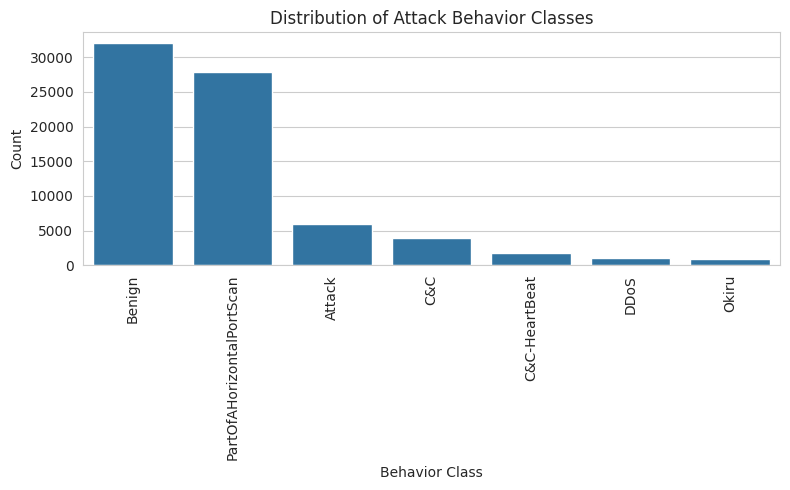

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x='detailed-label',
    order=final_df['detailed-label'].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Distribution of Attack Behavior Classes")
plt.xlabel("Behavior Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

BINARY LABEL DISTRIBUTION

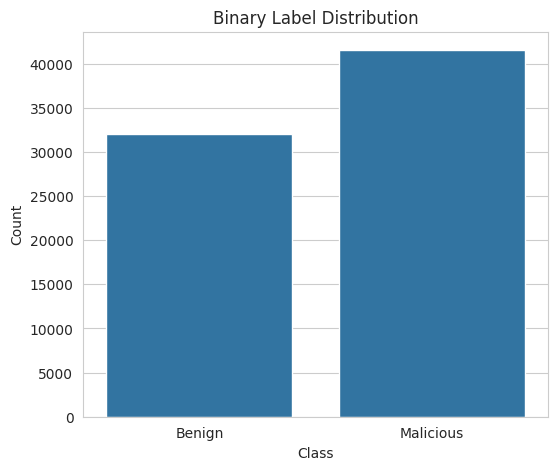

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=final_df,
    x='label'
)

plt.title("Binary Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

PROTOCOL DISTRIBUTION

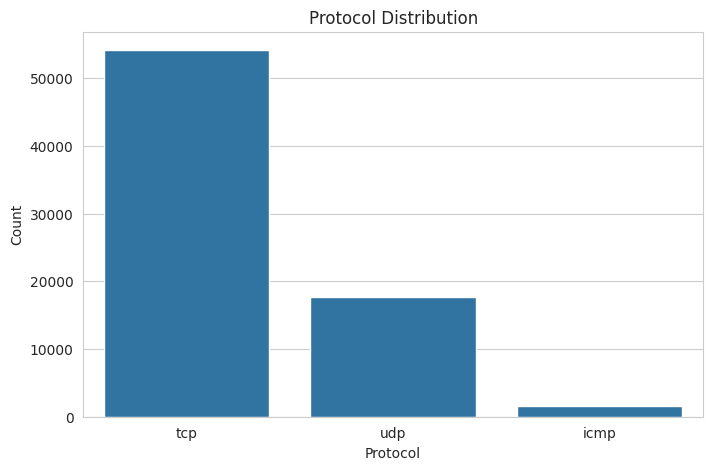

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x='proto',
    order=final_df['proto'].value_counts().index
)

plt.title("Protocol Distribution")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.show()

SERVICE DISTRIBUTION

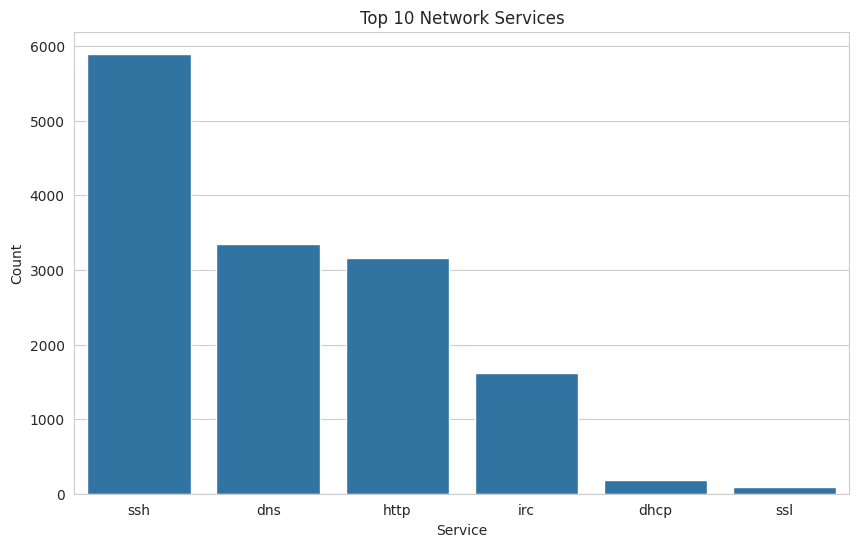

In [ ]:
top_services = final_df['service'].value_counts().head(10).index

plt.figure(figsize=(10,6))

sns.countplot(
    data=final_df[final_df['service'].isin(top_services)],
    x='service',
    order=top_services
)

plt.xticks(rotation=0)

plt.title("Top 10 Network Services")
plt.xlabel("Service")
plt.ylabel("Count")

plt.show()

CONNECTION STATE DISTRIBUTION

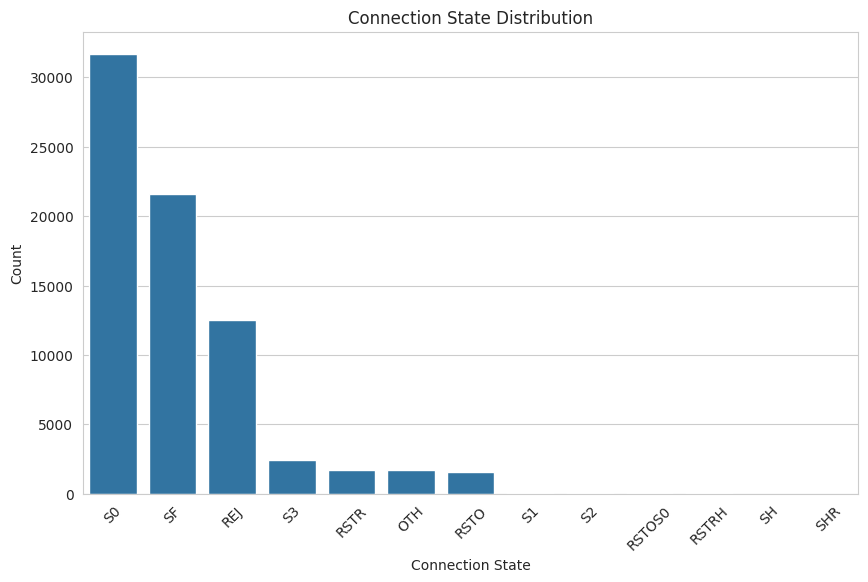

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=final_df,
    x='conn_state',
    order=final_df['conn_state'].value_counts().index
)

plt.title("Connection State Distribution")
plt.xlabel("Connection State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

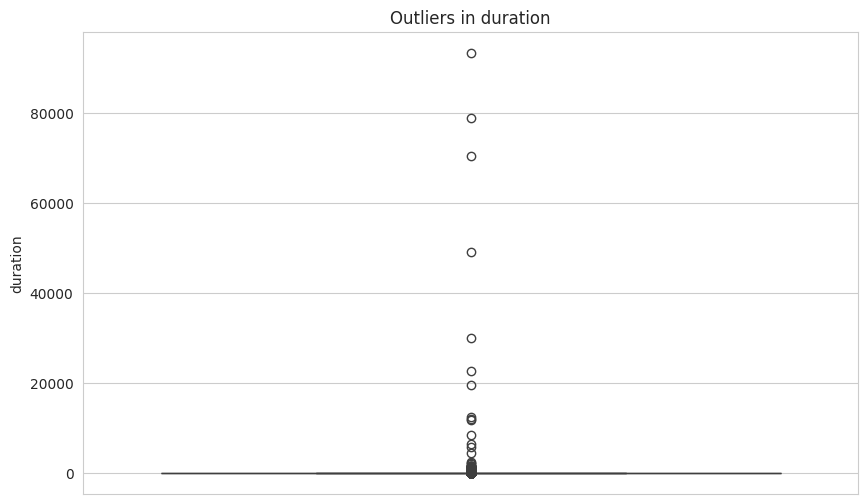

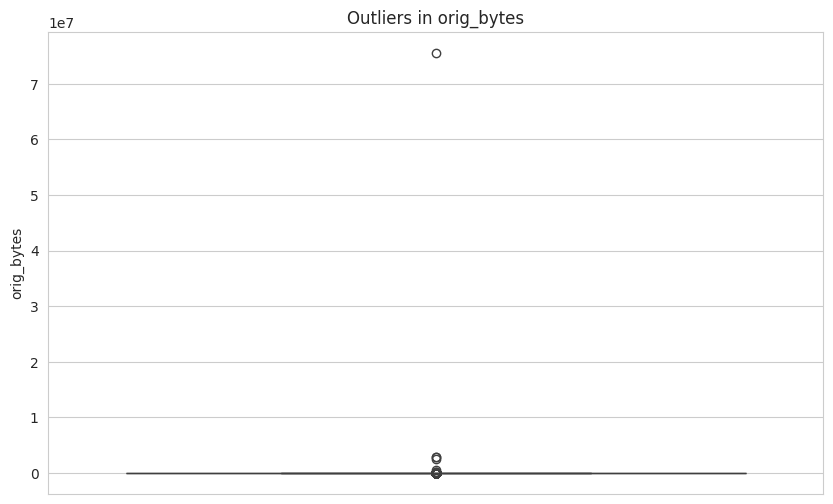

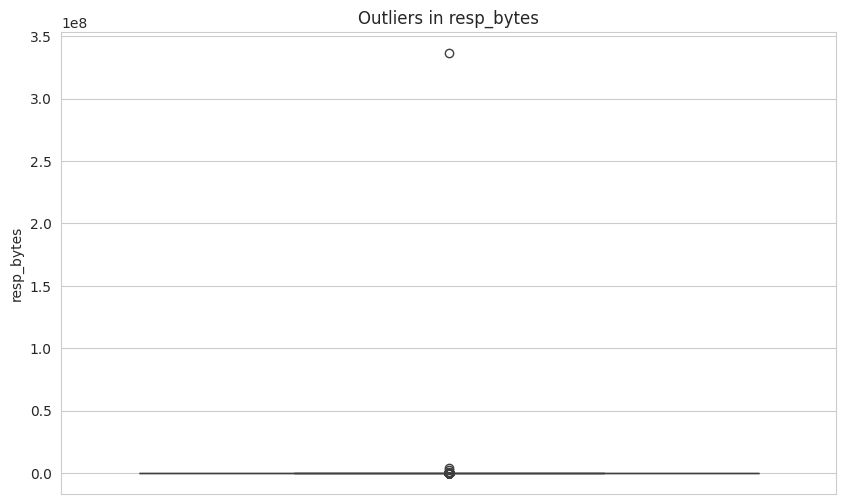

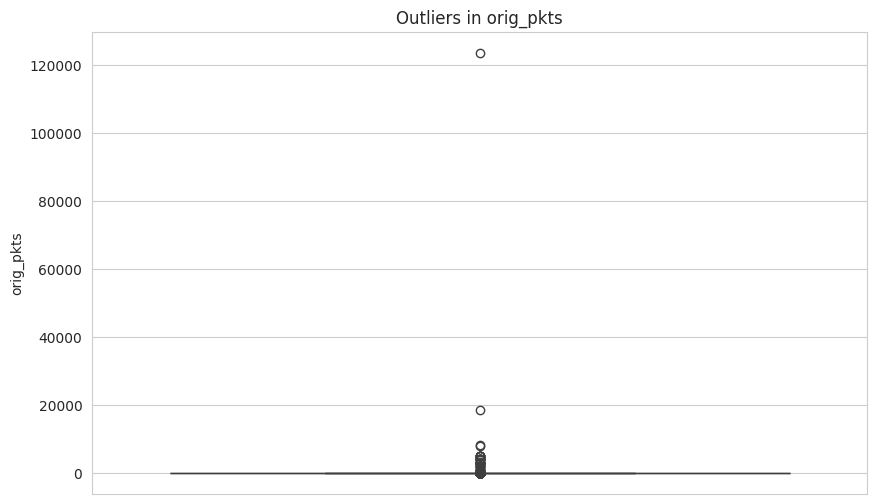

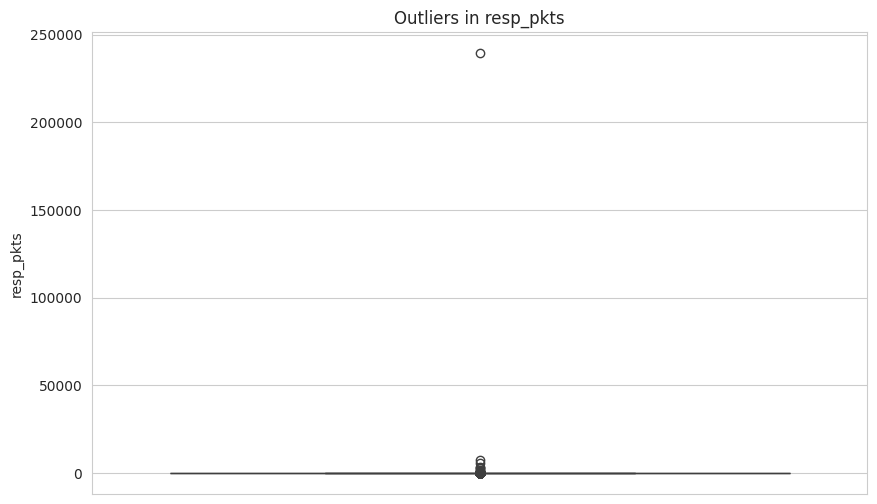

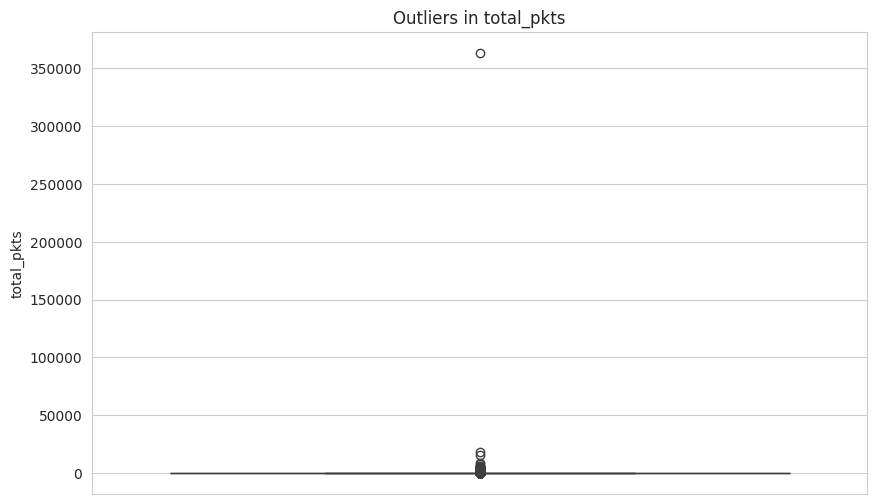

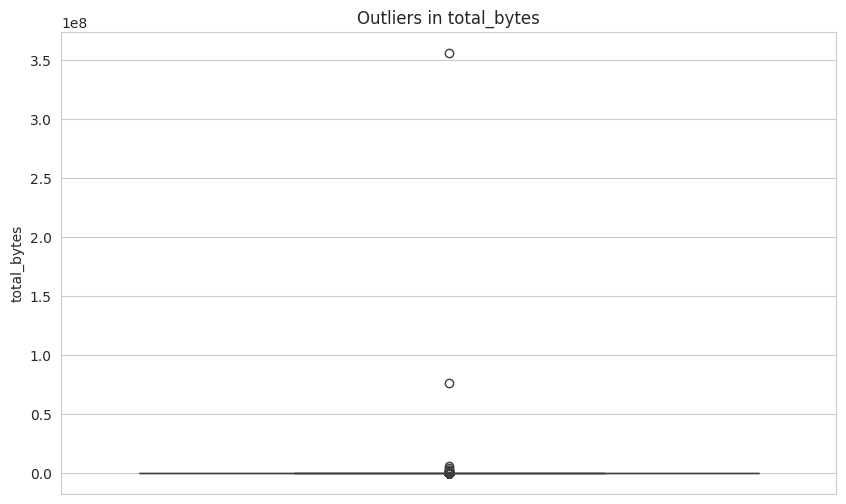

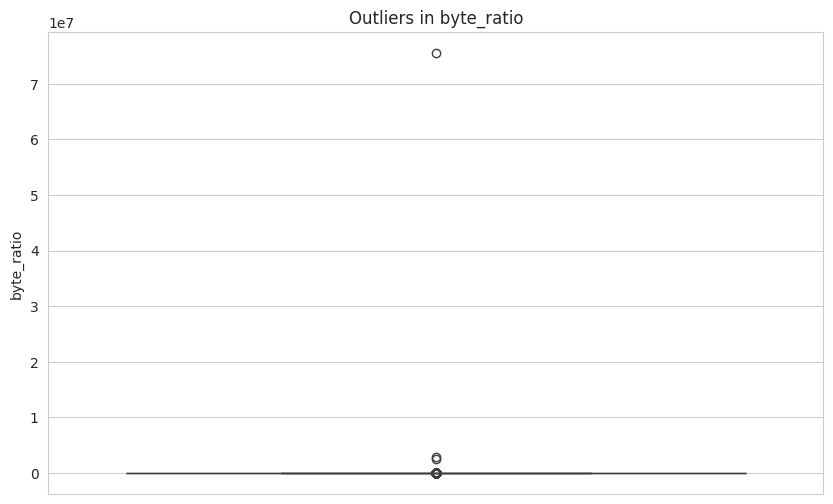

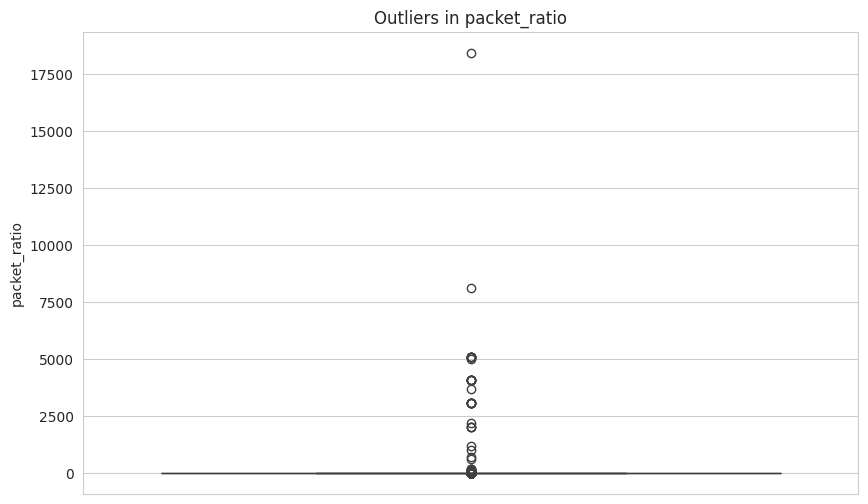

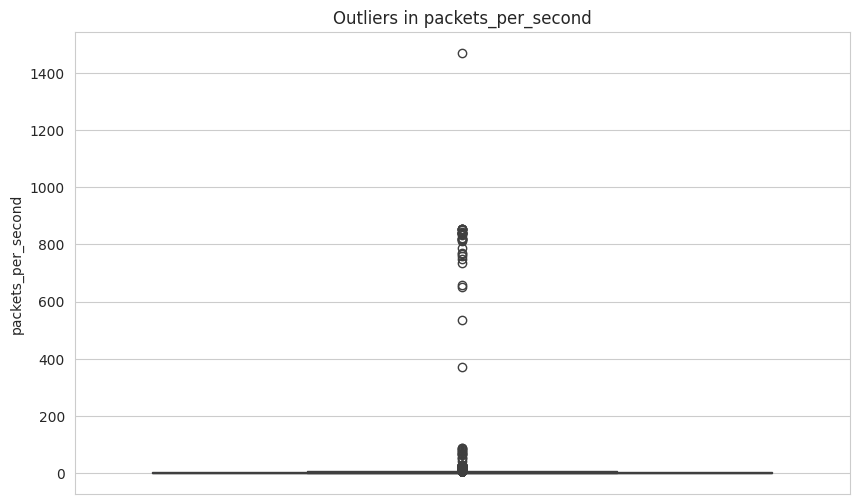

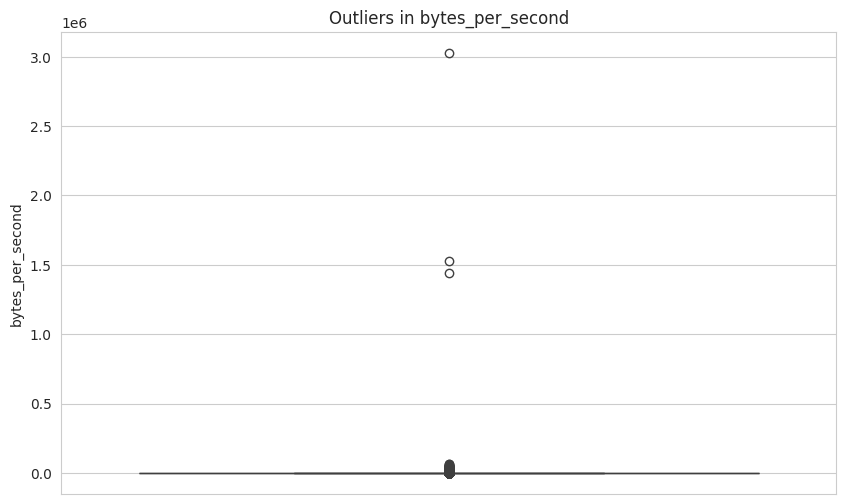

In [ ]:
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=final_df,
        y=feature
    )
    plt.title(f"Outliers in {feature}")
    plt.ylabel(feature)
    plt.show()

FEATURE DISTRIBUTIONS (VERY IMPORTANT)

In [ ]:
numerical_features = [
    'duration',
    'orig_bytes',
    'resp_bytes',
    'orig_pkts',
    'resp_pkts',
    'total_pkts',
    'total_bytes',
    'byte_ratio',
    'packet_ratio',
    'packets_per_second',
    'bytes_per_second'
]

HISTOGRAMS

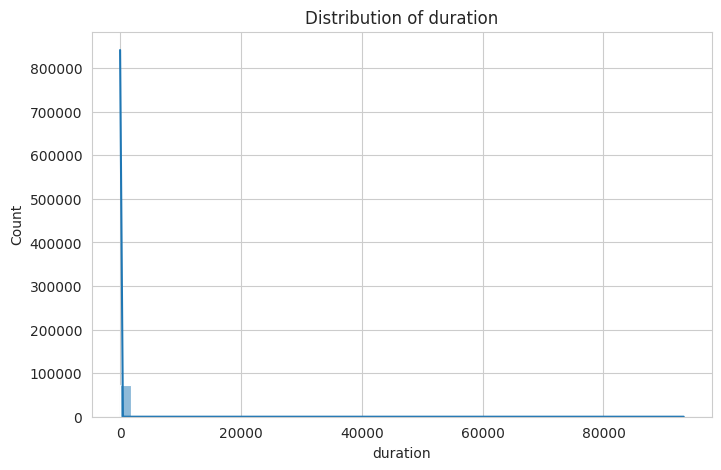

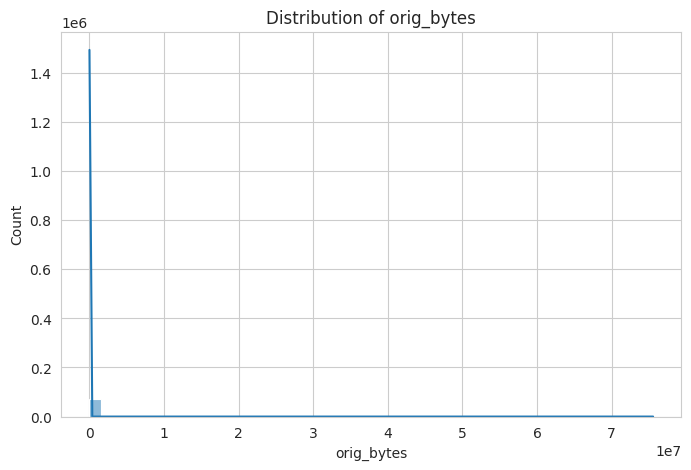

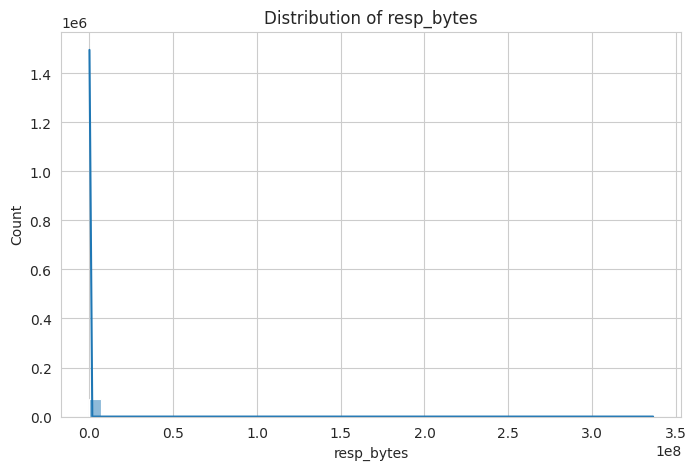

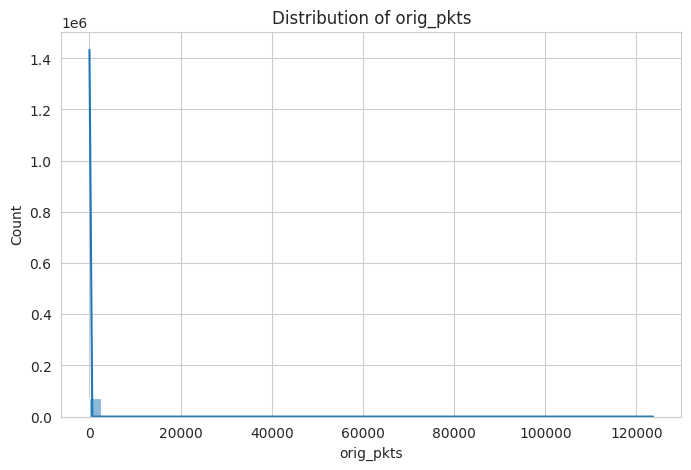

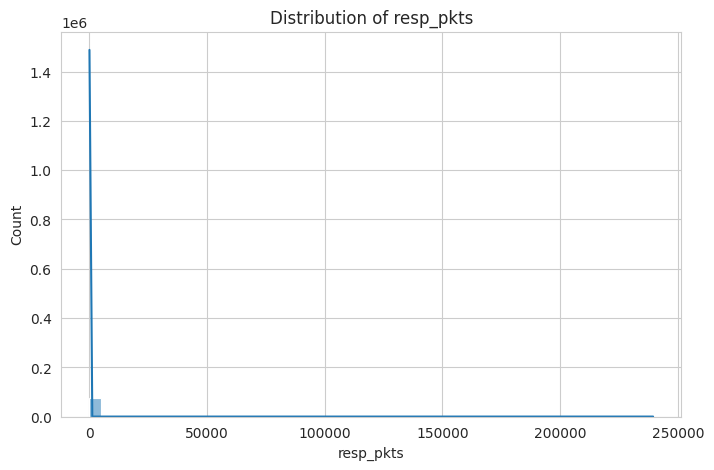

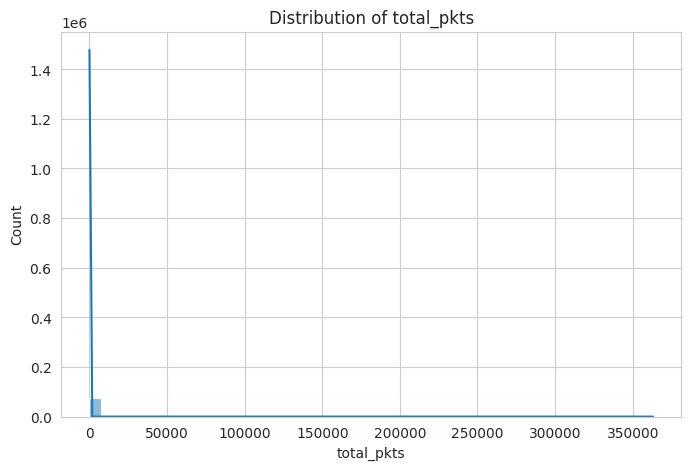

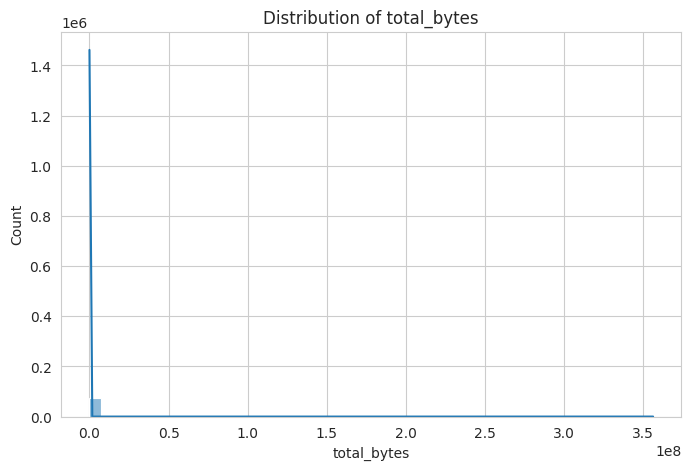

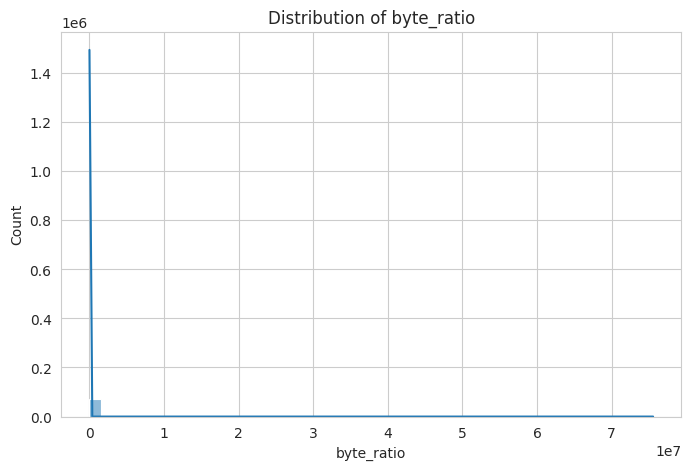

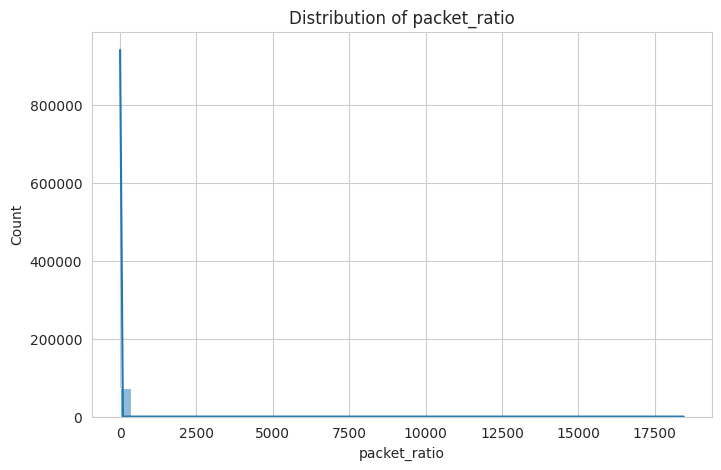

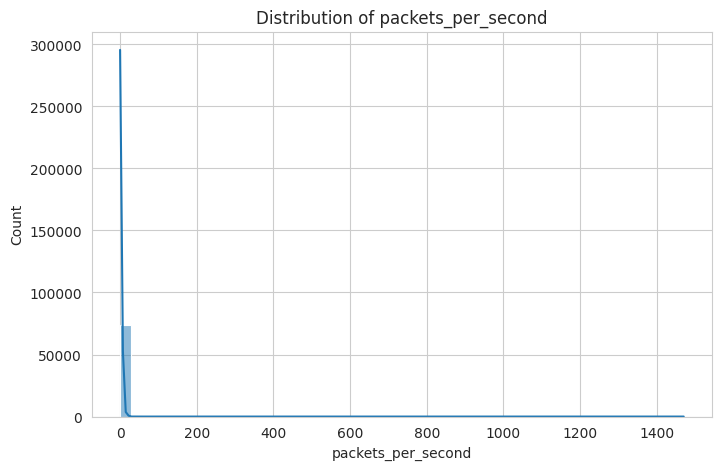

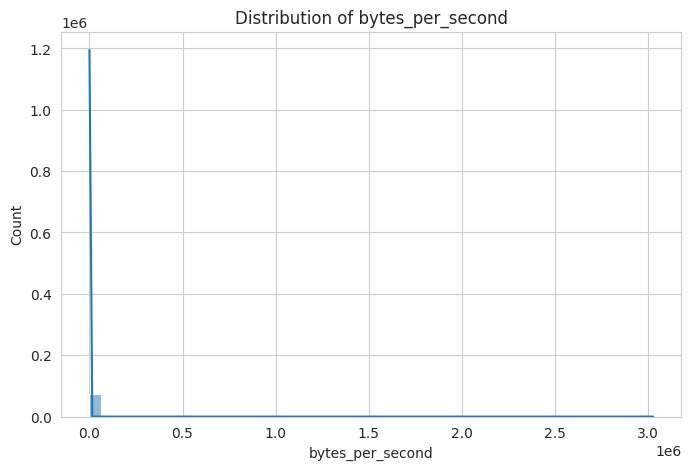

In [ ]:
for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        final_df[feature],
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {feature}")

    plt.show()

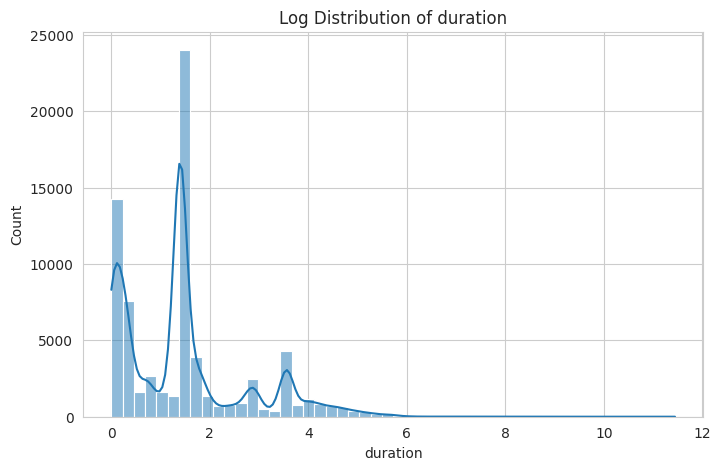

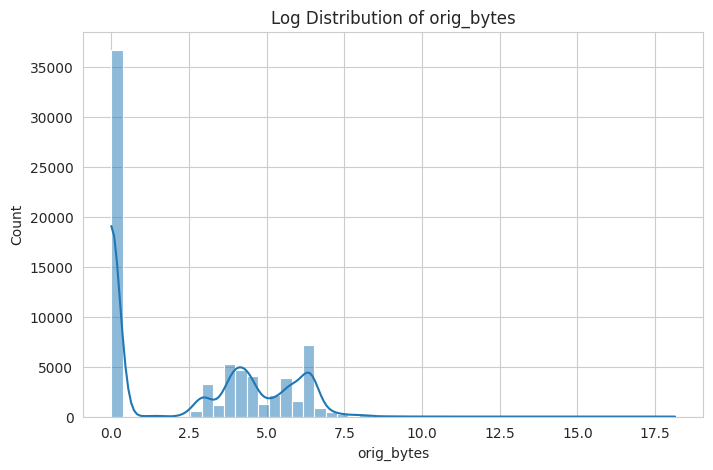

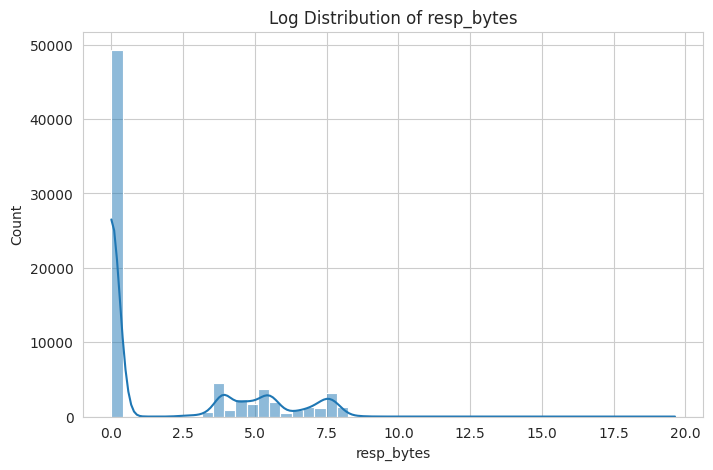

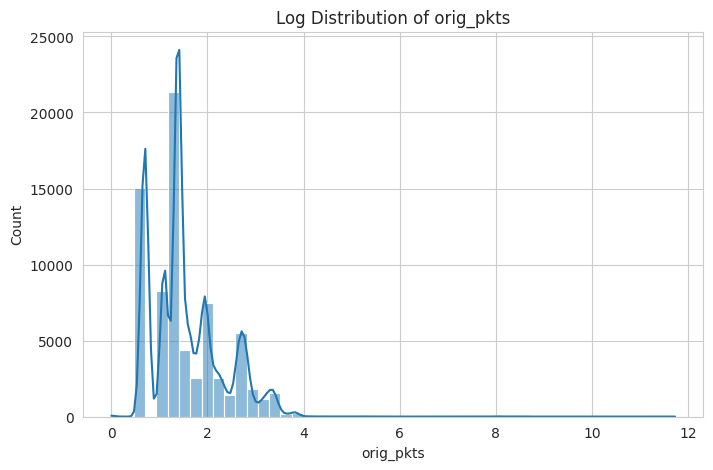

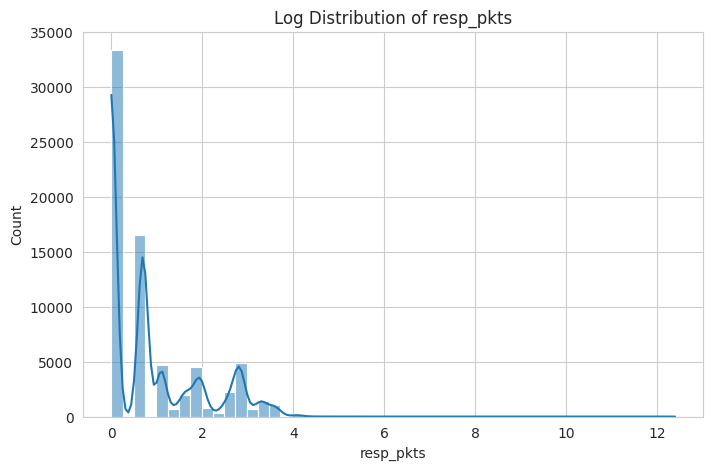

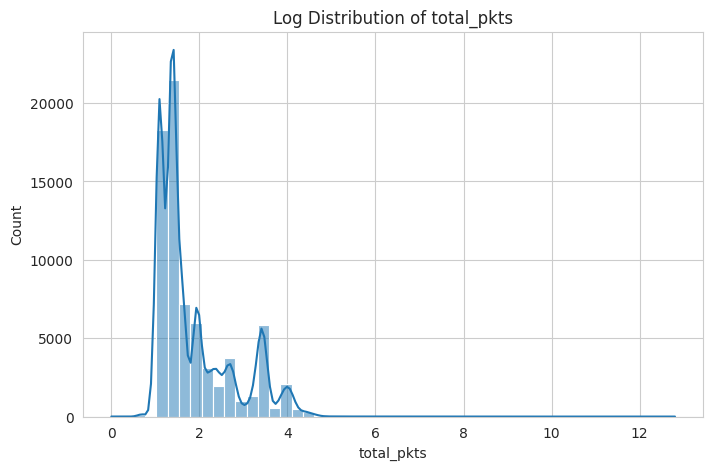

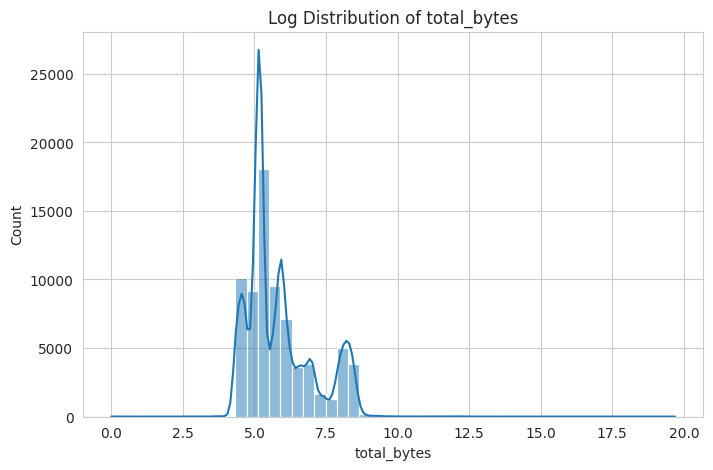

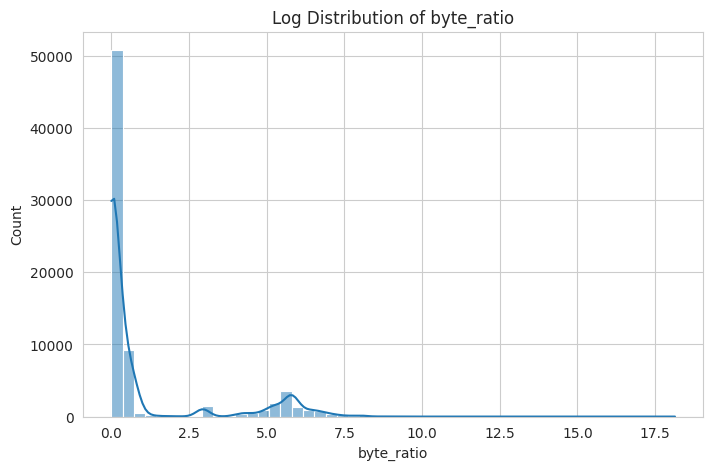

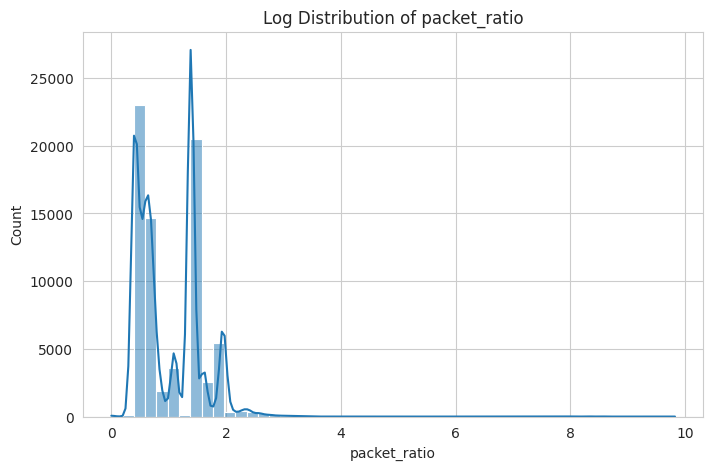

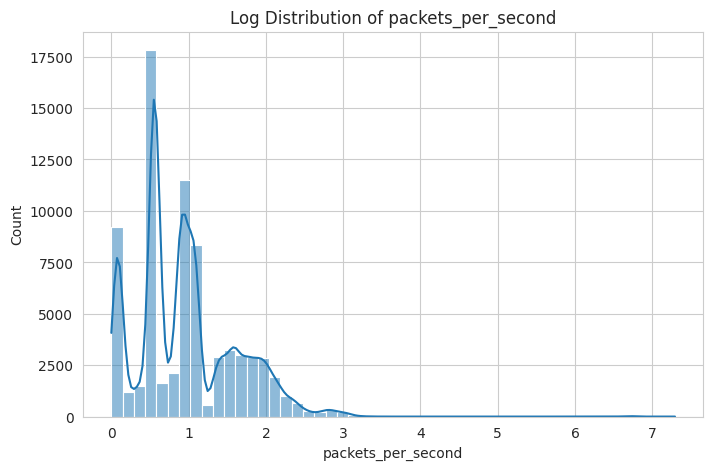

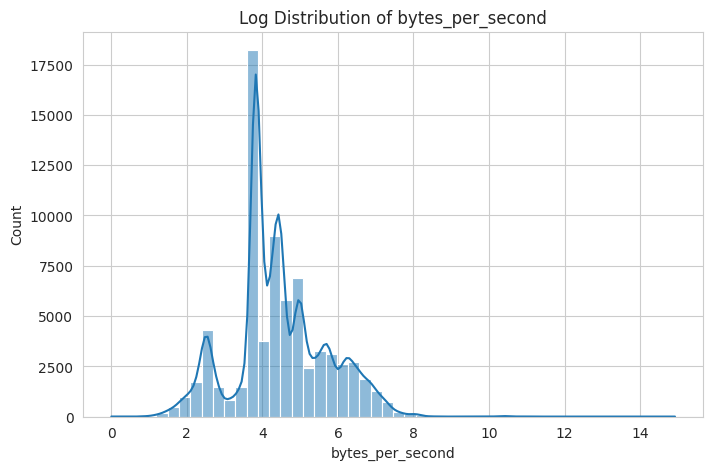

In [ ]:
for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        np.log1p(final_df[feature]),
        bins=50,
        kde=True
    )

    plt.title(f"Log Distribution of {feature}")

    plt.show()

CORRELATION HEATMAP

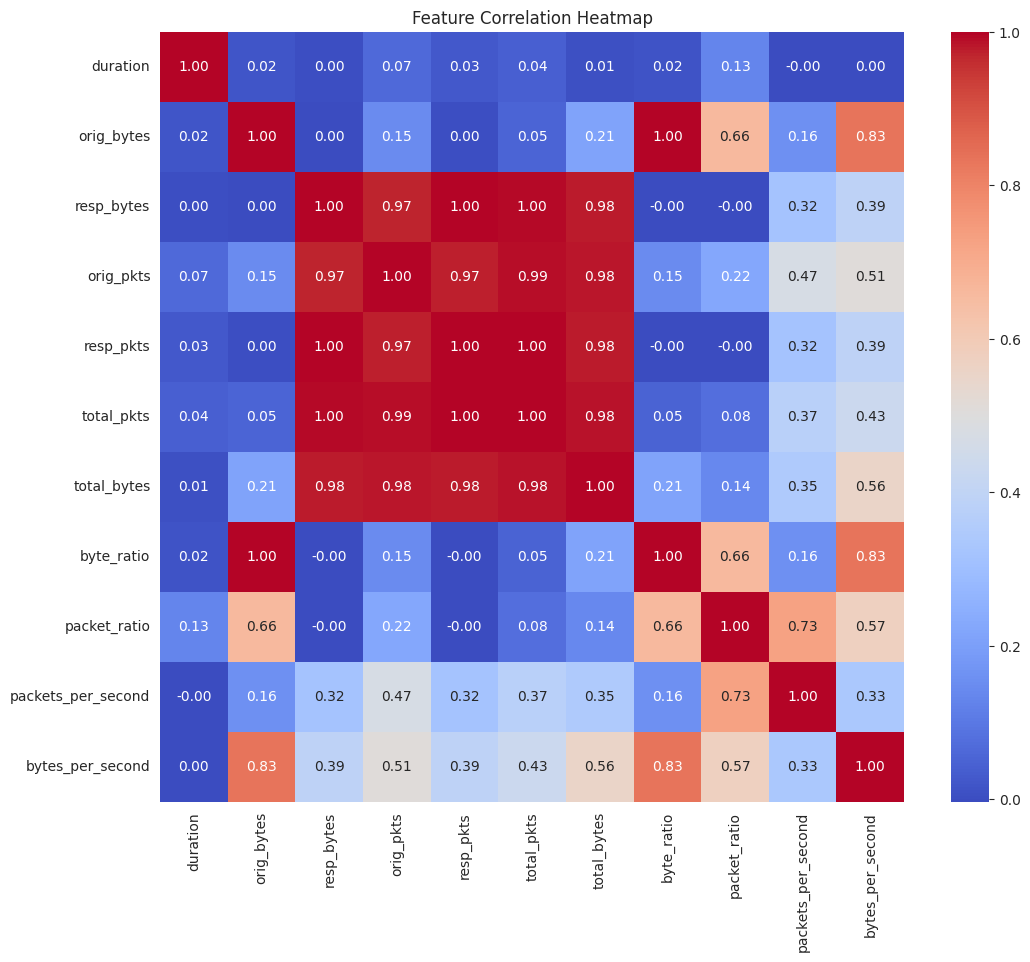

In [ ]:
plt.figure(figsize=(12,10))

correlation_matrix = final_df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

FEATURE DISTRIBUTION BY ATTACK CLASS

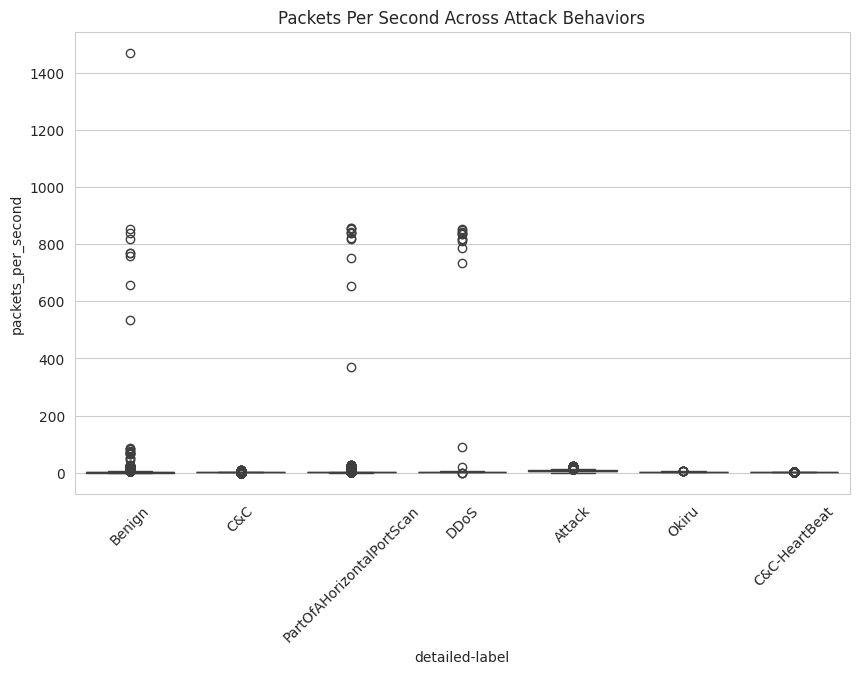

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=final_df,
    x='detailed-label',
    y='packets_per_second'
)

plt.xticks(rotation=45)

plt.title("Packets Per Second Across Attack Behaviors")

plt.show()

In [ ]:
features_to_compare = [
    'duration',
    'total_pkts',
    'total_bytes',
    'byte_ratio',
    'packet_ratio',
    'packets_per_second',
    'bytes_per_second'
]

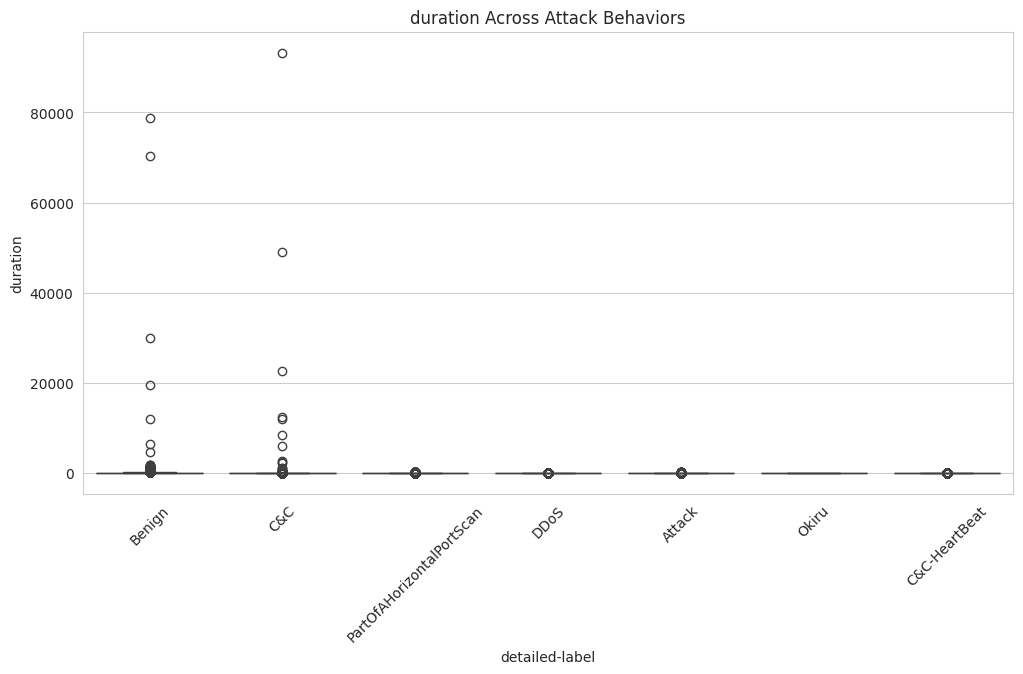

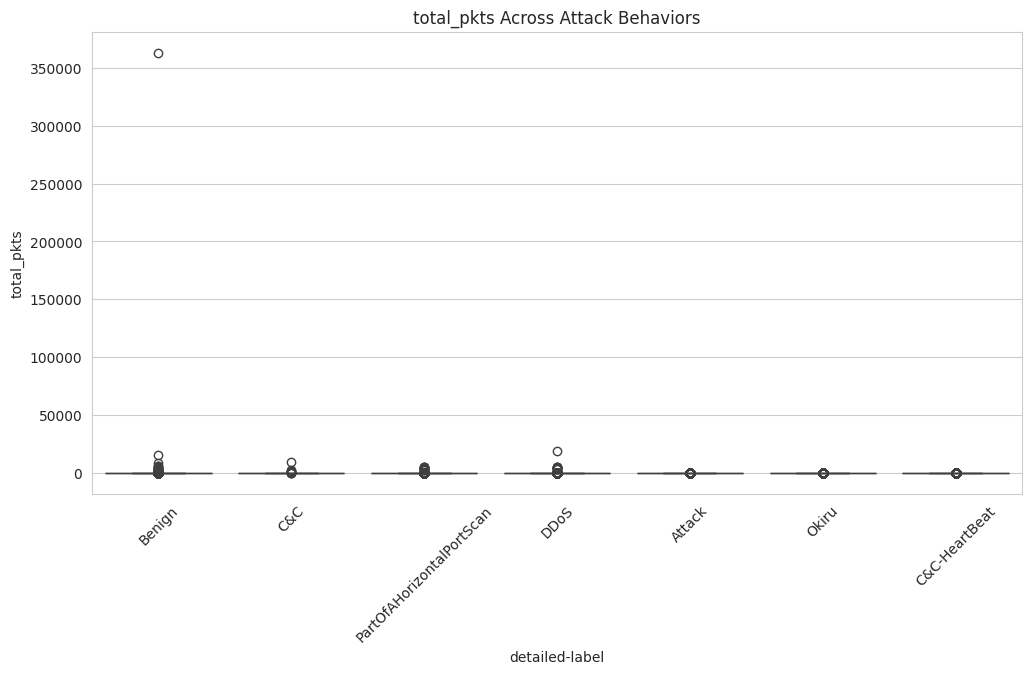

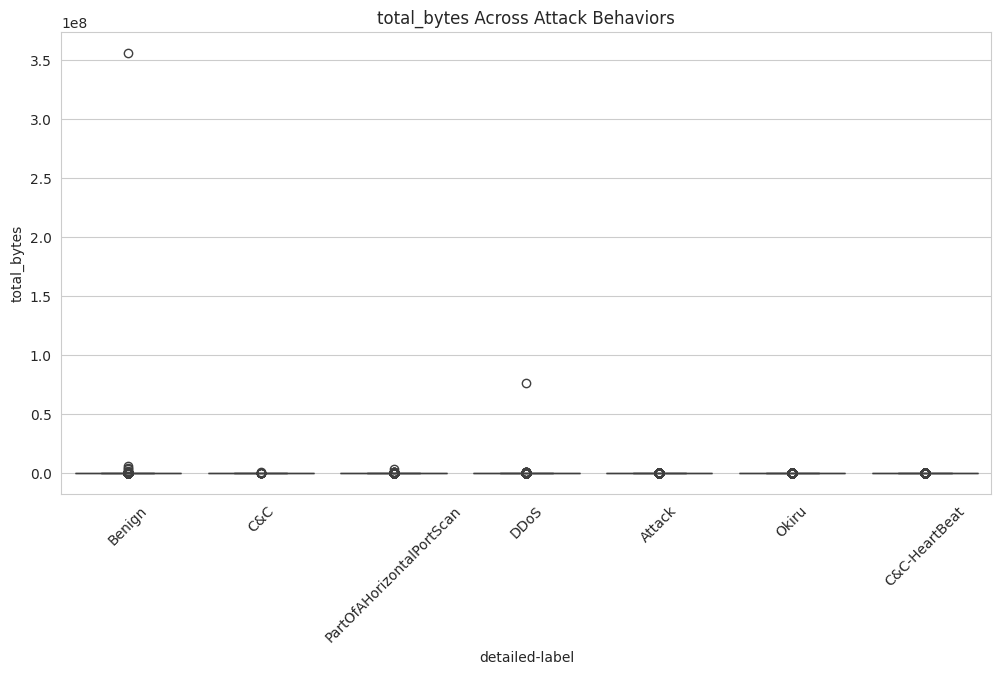

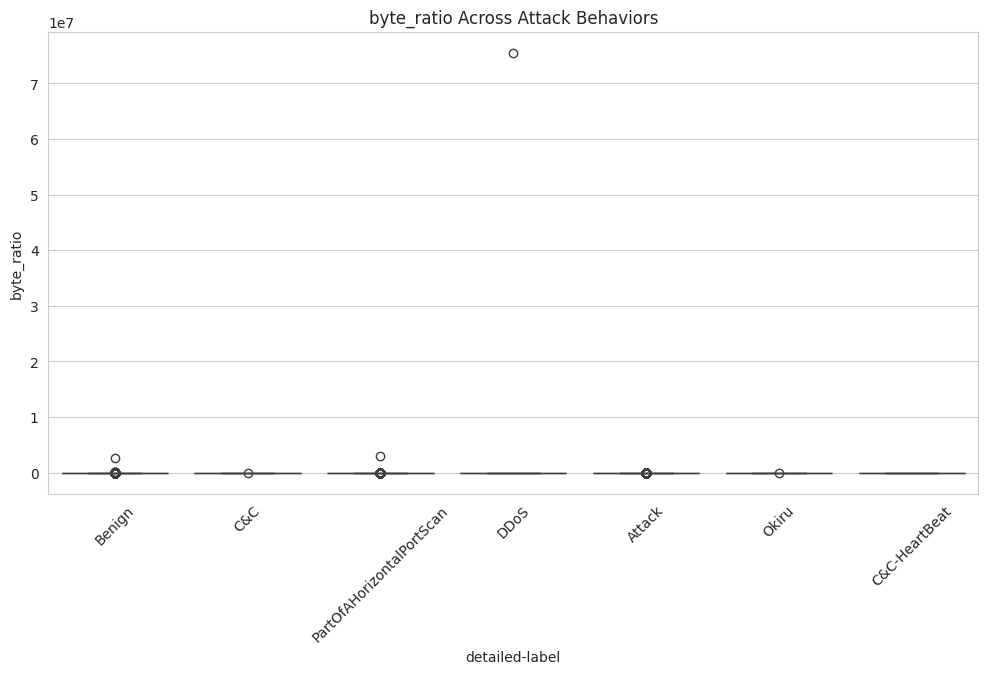

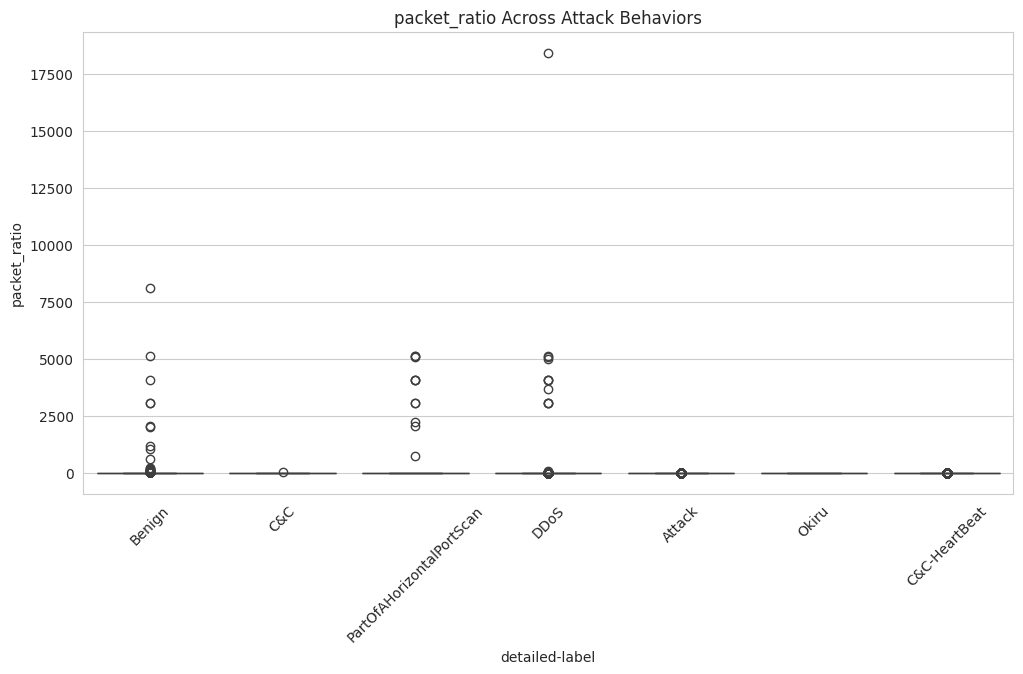

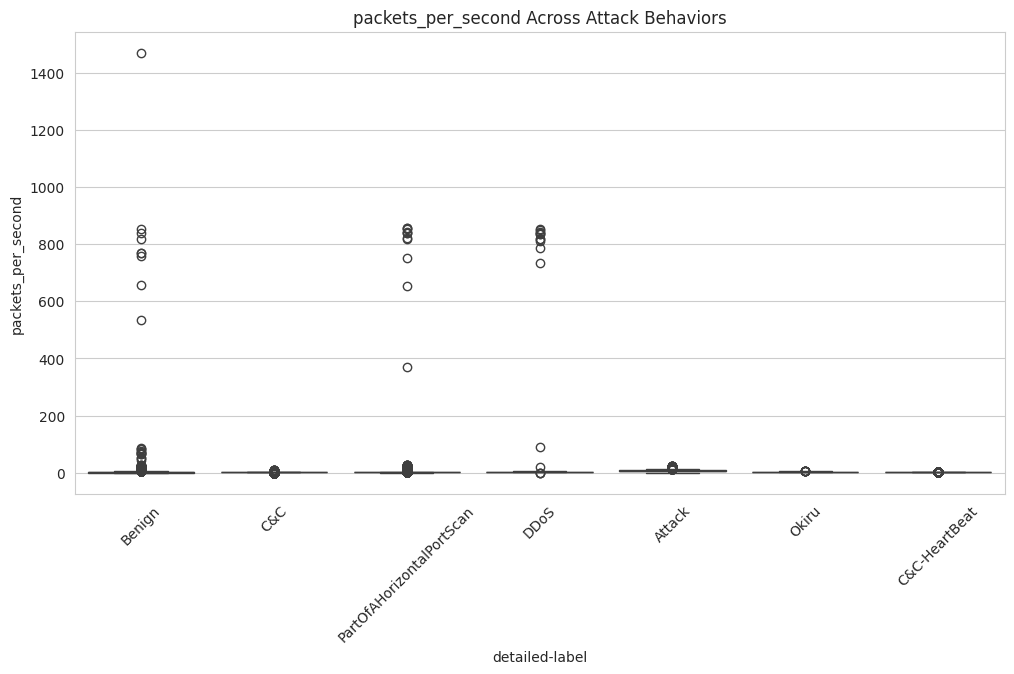

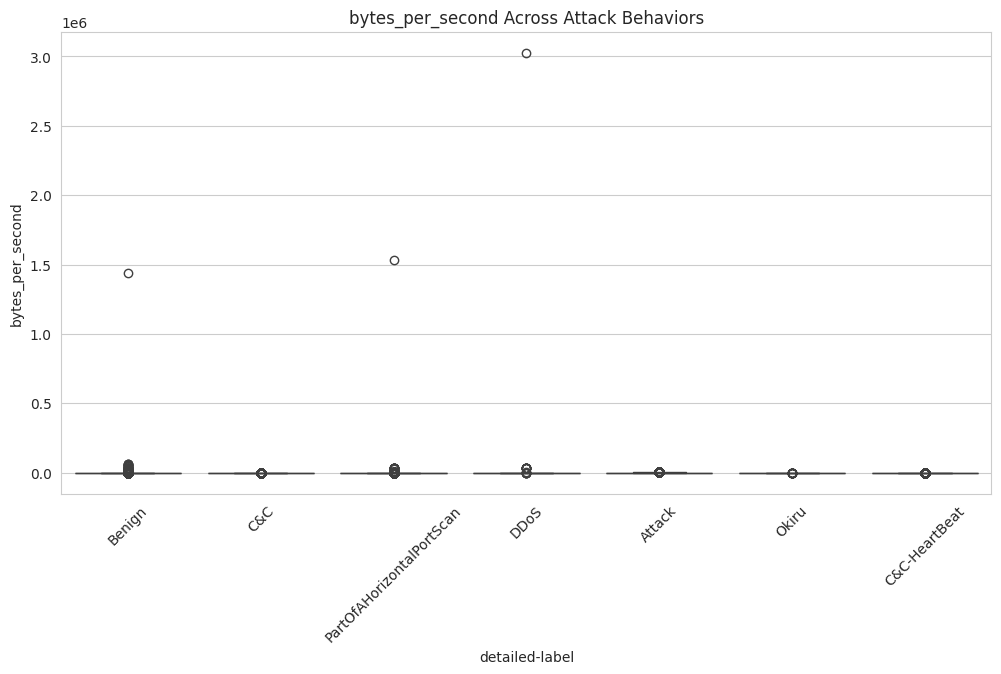

In [ ]:
for feature in features_to_compare:

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=final_df,
        x='detailed-label',
        y=feature
    )

    plt.xticks(rotation=45)

    plt.title(f"{feature} Across Attack Behaviors")

    plt.show()

VIOLIN PLOTS

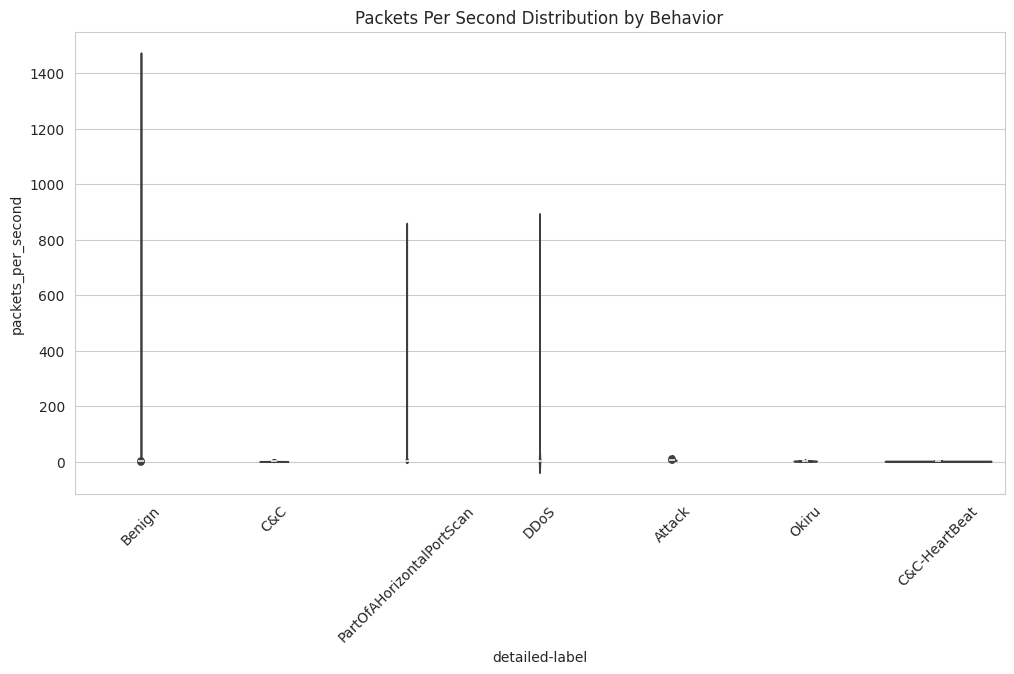

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=final_df,
    x='detailed-label',
    y='packets_per_second'
)

plt.xticks(rotation=45)

plt.title("Packets Per Second Distribution by Behavior")

plt.show()